生成蜜蜂行为与代码元素映射关系图...


C:\Users\赵俊熙\AppData\Local\Temp\ipykernel_23424\2428108668.py:109: UserWarning: Glyph 128029 (\N{HONEYBEE}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\赵俊熙\AppData\Local\Temp\ipykernel_23424\2428108668.py:109: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\赵俊熙\AppData\Local\Temp\ipykernel_23424\2428108668.py:109: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\赵俊熙\AppData\Local\Temp\ipykernel_23424\2428108668.py:109: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\赵俊熙\AppData\Local\Temp\ipykernel_23424\2428108668.py:109: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\赵俊熙\AppData\Local\Temp\ipykernel_23424\2428108668.py:109: UserWarning: Glyph 34588 (\N{CJK UNIFIED IDEOGRAPH-87

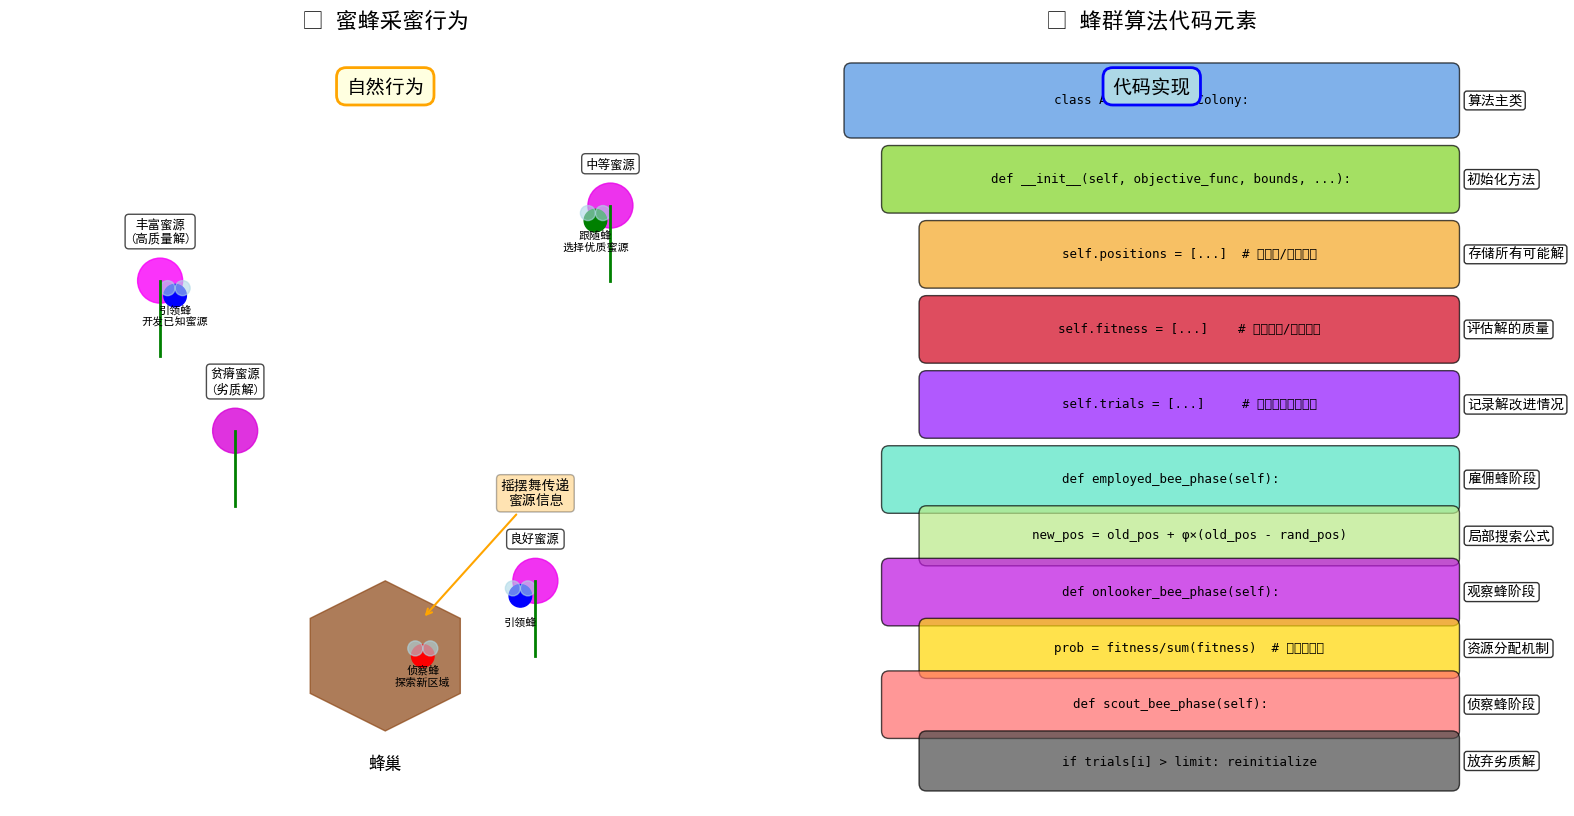


生成详细映射关系解释...
蜜蜂行为与蜂群算法代码元素详细映射关系

1. 蜜源 (Nectar Source) → 解向量 (Solution Vector)
   描述: 蜜蜂寻找的具体花丛位置，对应算法中的一个可能解
   蜜蜂示例: 坐标为(x,y)的花丛，花蜜丰富程度不同
   代码示例: positions[i] = [3.14, -2.71]  # 一个二维解
   算法作用: 代表优化问题的一个候选解决方案
--------------------------------------------------------------------------------

2. 花蜜量 (Nectar Amount) → 适应度值 (Fitness Value)
   描述: 蜜源的质量评估，决定吸引蜜蜂的数量
   蜜蜂示例: 花蜜越多，质量越高，吸引越多蜜蜂
   代码示例: fitness = 1/(1+abs(obj_func(x)))
   算法作用: 量化解的质量，指导搜索方向
--------------------------------------------------------------------------------

3. 侦察蜂 (Scout Bee) → 随机初始化 (Random Initialization)
   描述: 探索未知区域寻找新蜜源的蜜蜂
   蜜蜂示例: 随机飞到新区域探索潜在花丛
   代码示例: x = random.uniform(min, max)
   算法作用: 在搜索空间内广泛探索，避免遗漏好区域
--------------------------------------------------------------------------------

4. 引领蜂 (Employed Bee) → 局部搜索 (Local Search)
   描述: 在已知蜜源附近精细搜索的蜜蜂
   蜜蜂示例: 在好花丛周围寻找更多花朵
   代码示例: new_x = x + φ×(x - x_random)
   算法作用: 深度开发有希望的 region，提高解质量
----------------------------------------------------------

ValueError: 'red--' is not a valid format string (unrecognized character 'e')

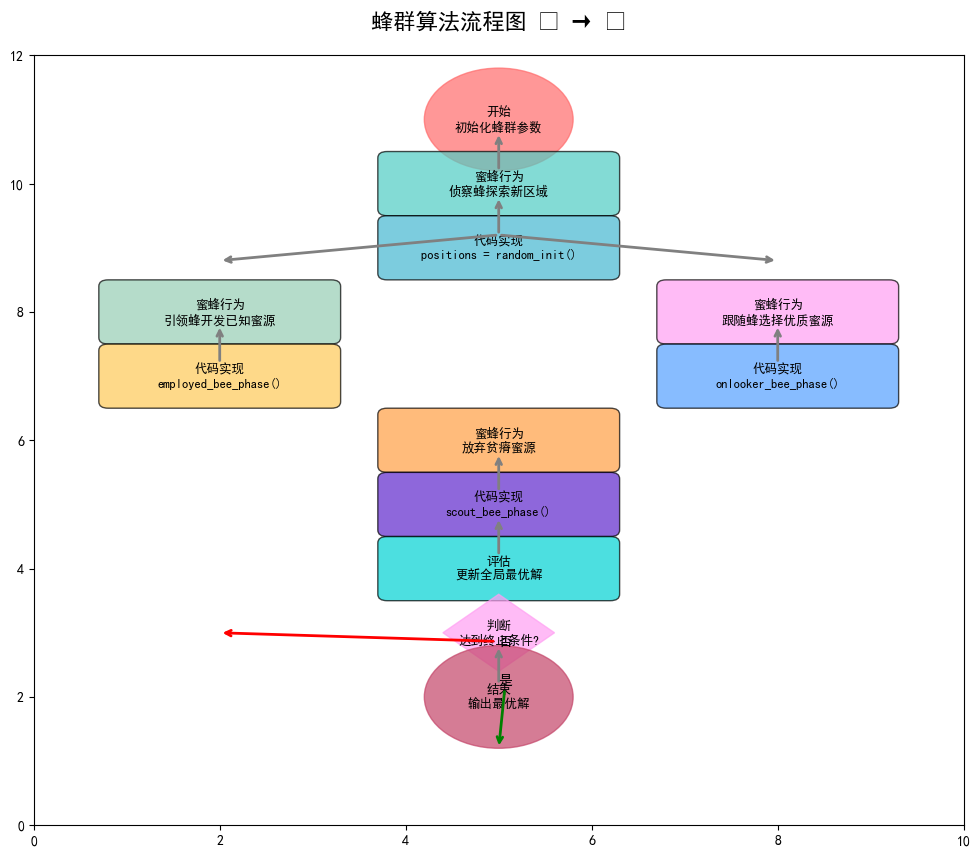

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch, Circle, Wedge


# 创建映射关系可视化
def create_bee_algorithm_mapping_diagram():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    plt.rcParams['font.sans-serif'] = ['SimHei']

    # 左侧：蜜蜂行为示意图
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_title('🐝 蜜蜂采蜜行为', fontsize=16, fontweight='bold', pad=20)

    # 绘制蜂巢
    hexagon = plt.Polygon([[5, 1], [6, 1.5], [6, 2.5], [5, 3], [4, 2.5], [4, 1.5]],
                          closed=True, color='#8B4513', alpha=0.7)
    ax1.add_patch(hexagon)
    ax1.text(5, 0.5, '蜂巢', ha='center', fontsize=12, fontweight='bold')

    # 绘制蜜源（花朵）
    flowers = [
        (2, 7, 0.9, '丰富蜜源\n(高质量解)'),
        (8, 8, 0.6, '中等蜜源'),
        (3, 5, 0.3, '贫瘠蜜源\n(劣质解)'),
        (7, 3, 0.7, '良好蜜源')
    ]

    for x, y, quality, label in flowers:
        # 花茎
        ax1.plot([x, x], [y, y - 1], 'g-', linewidth=2)
        # 花朵（颜色深浅表示蜜源质量）
        color_intensity = int(200 + quality * 55)
        flower = Circle((x, y), 0.3, color=f'#{color_intensity:02x}00{color_intensity:02x}', alpha=0.8)
        ax1.add_patch(flower)
        ax1.text(x, y + 0.5, label, ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    # 绘制蜜蜂
    bees = [
        (5.5, 2, 'scout', '侦察蜂\n探索新区域'),
        (2.2, 6.8, 'employed', '引领蜂\n开发已知蜜源'),
        (7.8, 7.8, 'onlooker', '跟随蜂\n选择优质蜜源'),
        (6.8, 2.8, 'employed', '引领蜂')
    ]

    bee_colors = {'scout': 'red', 'employed': 'blue', 'onlooker': 'green'}

    for x, y, bee_type, label in bees:
        # 蜜蜂身体
        bee_body = Circle((x, y), 0.15, color=bee_colors[bee_type])
        ax1.add_patch(bee_body)
        # 蜜蜂翅膀
        wing1 = Circle((x - 0.1, y + 0.1), 0.1, color='lightblue', alpha=0.6)
        wing2 = Circle((x + 0.1, y + 0.1), 0.1, color='lightblue', alpha=0.6)
        ax1.add_patch(wing1)
        ax1.add_patch(wing2)
        ax1.text(x, y - 0.4, label, ha='center', fontsize=8)

    # 绘制信息传递（摇摆舞）
    ax1.annotate('摇摆舞传递\n蜜源信息', xy=(5.5, 2.5), xytext=(7, 4),
                 arrowprops=dict(arrowstyle='->', lw=1.5, color='orange'),
                 ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="orange", alpha=0.3))

    ax1.set_aspect('equal')
    ax1.axis('off')

    # 右侧：代码元素示意图
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.set_title('💻 蜂群算法代码元素', fontsize=16, fontweight='bold', pad=20)

    # 代码结构框
    code_boxes = [
        (1, 9, 8, 0.8, 'class ArtificialBeeColony:', '#4A90E2', '算法主类'),
        (1.5, 8, 7.5, 0.7, 'def __init__(self, objective_func, bounds, ...):', '#7ED321', '初始化方法'),
        (2, 7, 7, 0.7, 'self.positions = [...]  # 解向量/蜜源位置', '#F5A623', '存储所有可能解'),
        (2, 6, 7, 0.7, 'self.fitness = [...]    # 适应度值/蜜源质量', '#D0021B', '评估解的质量'),
        (2, 5, 7, 0.7, 'self.trials = [...]     # 未改进次数计数器', '#9013FE', '记录解改进情况'),
        (1.5, 4, 7.5, 0.7, 'def employed_bee_phase(self):', '#50E3C2', '雇佣蜂阶段'),
        (2, 3.3, 7, 0.6, 'new_pos = old_pos + φ×(old_pos - rand_pos)', '#B8E986', '局部搜索公式'),
        (1.5, 2.5, 7.5, 0.7, 'def onlooker_bee_phase(self):', '#BD10E0', '观察蜂阶段'),
        (2, 1.8, 7, 0.6, 'prob = fitness/sum(fitness)  # 轮盘赌选择', '#FFD700', '资源分配机制'),
        (1.5, 1, 7.5, 0.7, 'def scout_bee_phase(self):', '#FF6B6B', '侦察蜂阶段'),
        (2, 0.3, 7, 0.6, 'if trials[i] > limit: reinitialize', '#4A4A4A', '放弃劣质解')
    ]

    for x, y, width, height, text, color, desc in code_boxes:
        rect = FancyBboxPatch((x, y), width, height,
                              boxstyle="round,pad=0.1",
                              facecolor=color, alpha=0.7, edgecolor='black')
        ax2.add_patch(rect)
        ax2.text(x + width / 2, y + height / 2, text, ha='center', va='center',
                 fontsize=9, fontfamily='monospace')

        # 添加描述
        ax2.text(x + width + 0.2, y + height / 2, desc, va='center', fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

    ax2.set_aspect('equal')
    ax2.axis('off')

    # 添加连接线说明
    ax1.text(5, 9.5, '自然行为', ha='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", fc="lightyellow", ec="orange", lw=2))
    ax2.text(5, 9.5, '代码实现', ha='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", fc="lightblue", ec="blue", lw=2))

    plt.tight_layout()
    plt.show()


# 创建详细的映射关系解释
def create_detailed_mapping_explanation():
    mappings = [
        {
            "bee_behavior": "蜜源 (Nectar Source)",
            "code_element": "解向量 (Solution Vector)",
            "description": "蜜蜂寻找的具体花丛位置，对应算法中的一个可能解",
            "bee_example": "坐标为(x,y)的花丛，花蜜丰富程度不同",
            "code_example": "positions[i] = [3.14, -2.71]  # 一个二维解",
            "purpose": "代表优化问题的一个候选解决方案"
        },
        {
            "bee_behavior": "花蜜量 (Nectar Amount)",
            "code_element": "适应度值 (Fitness Value)",
            "description": "蜜源的质量评估，决定吸引蜜蜂的数量",
            "bee_example": "花蜜越多，质量越高，吸引越多蜜蜂",
            "code_example": "fitness = 1/(1+abs(obj_func(x)))",
            "purpose": "量化解的质量，指导搜索方向"
        },
        {
            "bee_behavior": "侦察蜂 (Scout Bee)",
            "code_element": "随机初始化 (Random Initialization)",
            "description": "探索未知区域寻找新蜜源的蜜蜂",
            "bee_example": "随机飞到新区域探索潜在花丛",
            "code_example": "x = random.uniform(min, max)",
            "purpose": "在搜索空间内广泛探索，避免遗漏好区域"
        },
        {
            "bee_behavior": "引领蜂 (Employed Bee)",
            "code_element": "局部搜索 (Local Search)",
            "description": "在已知蜜源附近精细搜索的蜜蜂",
            "bee_example": "在好花丛周围寻找更多花朵",
            "code_example": "new_x = x + φ×(x - x_random)",
            "purpose": "深度开发有希望的 region，提高解质量"
        },
        {
            "bee_behavior": "摇摆舞 (Waggle Dance)",
            "code_element": "概率选择 (Probability Selection)",
            "description": "蜜蜂通过舞蹈传递蜜源信息的方式",
            "bee_example": "舞蹈持续时间表示蜜源距离和质量",
            "code_example": "prob[i] = fitness[i]/sum(fitness)",
            "purpose": "根据解质量分配计算资源，实现优胜劣汰"
        },
        {
            "bee_behavior": "跟随蜂 (Onlooker Bee)",
            "code_element": "资源分配 (Resource Allocation)",
            "description": "根据舞蹈信息选择蜜源的蜜蜂",
            "bee_example": "观察舞蹈后选择跟随哪个引领蜂",
            "code_example": "idx = roulette_wheel_select(probabilities)",
            "purpose": "将搜索努力集中在有潜力的解上"
        },
        {
            "bee_behavior": "放弃贫瘠蜜源 (Abandon Poor Source)",
            "code_element": "重新初始化 (Reinitialization)",
            "description": "放弃花蜜枯竭的蜜源，寻找新的机会",
            "bee_example": "离开长时间没有新花蜜的花丛",
            "code_example": "if trials > limit: x = random_position()",
            "purpose": "跳出局部最优，保持种群多样性"
        }
    ]

    # 打印详细的映射解释
    print("=" * 80)
    print("蜜蜂行为与蜂群算法代码元素详细映射关系")
    print("=" * 80)

    for i, mapping in enumerate(mappings, 1):
        print(f"\n{i}. {mapping['bee_behavior']} → {mapping['code_element']}")
        print(f"   描述: {mapping['description']}")
        print(f"   蜜蜂示例: {mapping['bee_example']}")
        print(f"   代码示例: {mapping['code_example']}")
        print(f"   算法作用: {mapping['purpose']}")
        print("-" * 80)


# 创建算法流程图
def create_algorithm_flowchart():
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.set_title('蜂群算法流程图 🐝 → 💻', fontsize=16, fontweight='bold', pad=20)

    # 绘制流程图步骤
    steps = [
        (5, 11, '开始', '初始化蜂群参数', '#FF6B6B'),
        (5, 10, '蜜蜂行为', '侦察蜂探索新区域', '#4ECDC4'),
        (5, 9, '代码实现', 'positions = random_init()', '#45B7D1'),
        (2, 8, '蜜蜂行为', '引领蜂开发已知蜜源', '#96CEB4'),
        (2, 7, '代码实现', 'employed_bee_phase()', '#FECA57'),
        (8, 8, '蜜蜂行为', '跟随蜂选择优质蜜源', '#FF9FF3'),
        (8, 7, '代码实现', 'onlooker_bee_phase()', '#54A0FF'),
        (5, 6, '蜜蜂行为', '放弃贫瘠蜜源', '#FF9F43'),
        (5, 5, '代码实现', 'scout_bee_phase()', '#5F27CD'),
        (5, 4, '评估', '更新全局最优解', '#00D2D3'),
        (5, 3, '判断', '达到终止条件?', '#FF9FF3'),
        (5, 2, '结束', '输出最优解', '#C44569'),
    ]

    # 绘制步骤框
    for x, y, step_type, text, color in steps:
        if step_type in ['开始', '结束']:
            # 椭圆形状
            ax.add_patch(plt.Circle((x, y), 0.8, color=color, alpha=0.7))
        elif step_type == '判断':
            # 菱形形状
            diamond = plt.Polygon([[x, y + 0.6], [x + 0.6, y], [x, y - 0.6], [x - 0.6, y]],
                                  color=color, alpha=0.7)
            ax.add_patch(diamond)
        else:
            # 矩形形状
            rect = FancyBboxPatch((x - 1.2, y - 0.4), 2.4, 0.8,
                                  boxstyle="round,pad=0.1",
                                  facecolor=color, alpha=0.7)
            ax.add_patch(rect)

        ax.text(x, y, f"{step_type}\n{text}", ha='center', va='center',
                fontsize=9, fontweight='bold')

    # 绘制连接线
    connections = [
        ((5, 10.2), (5, 10.8)),  # 开始 -> 侦察蜂
        ((5, 9.2), (5, 9.8)),  # 初始化 -> 引领蜂
        ((2, 7.2), (2, 7.8)),  # 雇佣蜂 -> 分支
        ((8, 7.2), (8, 7.8)),  # 观察蜂 -> 合并
        ((5, 5.2), (5, 5.8)),  # 侦察蜂 -> 评估
        ((5, 4.2), (5, 4.8)),  # 评估 -> 判断
        ((5, 2.2), (5, 2.8)),  # 判断 -> 结束
    ]

    for (x1, y1), (x2, y2) in connections:
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

    # 分支箭头
    ax.annotate("", xy=(2, 8.8), xytext=(5, 9.2),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    ax.annotate("", xy=(8, 8.8), xytext=(5, 9.2),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

    # 判断分支
    ax.annotate("是", xy=(5, 1.2), xytext=(5, 2.2),
                arrowprops=dict(arrowstyle='->', lw=2, color='green'))
    ax.annotate("否", xy=(2, 3), xytext=(5, 2.8),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
    ax.plot([2, 2], [3, 8.8], 'red--', lw=2)  # 循环返回线

    ax.set_aspect('equal')
    ax.axis('off')

    # 添加图例
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B', markersize=10, label='开始/结束'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#4ECDC4', markersize=10, label='蜜蜂行为步骤'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#45B7D1', markersize=10, label='代码实现步骤'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#FF9FF3', markersize=10, label='判断步骤'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    plt.tight_layout()
    plt.show()


# 执行所有可视化
print("生成蜜蜂行为与代码元素映射关系图...")
create_bee_algorithm_mapping_diagram()

print("\n生成详细映射关系解释...")
create_detailed_mapping_explanation()

print("\n生成蜂群算法流程图...")
create_algorithm_flowchart()